# PyTorch Dual Disentanglement (From Scratch)

## Lib

In [8]:
"""
From the NYU DL course. TODO Check how to reference/cite it later.
"""

import matplotlib as mpl
import numpy as np
import torch
from IPython.display import clear_output
from matplotlib import pyplot as plt


def set_default(figsize=(10, 10), dpi=100):
    plt.style.use(['dark_background', 'bmh'])
    plt.rc('axes', facecolor='k')
    plt.rc('figure', facecolor='k')
    plt.rc('figure', figsize=figsize, dpi=dpi)


def plot_data(X, y, d=0, auto=False, zoom=1, title='Training data (x, y)', point_colors=None):
    X = X.cpu()
    y = y.cpu()
    # If per-point colors provided, use them (accept RGB Nx3 or scalar iterable),
    # otherwise fall back to class-based colormap
    if point_colors is not None:
        try:
            s = plt.scatter(X.numpy()[:, 0], X.numpy()[:, 1], c=point_colors, s=20)
        except Exception:
            s = plt.scatter(X.numpy()[:, 0], X.numpy()[:, 1], c=point_colors, s=20, cmap=plt.cm.Spectral)
    else:
        s = plt.scatter(X.numpy()[:, 0], X.numpy()[:, 1], c=y, s=20, cmap=plt.cm.Spectral)
    plt.axis('square')
    plt.axis(np.array((-1.1, 1.1, -1.1, 1.1)) * zoom)
    if auto is True: plt.axis('equal')
    plt.axis('off')

    _m, _c = 0, '.35'
    plt.axvline(0, ymin=_m, color=_c, lw=1)
    plt.axhline(0, xmin=_m, color=_c, lw=1)
    plt.title(title)
    return s


def plot_model(X, y, model, point_colors=None):
    model.cpu()
    mesh = torch.arange(-1.1, 1.11, 0.01)
    xx, yy = torch.meshgrid(mesh, mesh, indexing='xy')
    with torch.no_grad():
        data = torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=1)
        Z = model(data)
    Z = Z.argmax(dim=1).reshape(xx.shape)
    plt.contourf(xx.numpy(), yy.numpy(), Z, cmap=plt.cm.Spectral, alpha=0.3)
    plot_data(X, y, point_colors=point_colors)
    plt.title('Model decision boundaries')


def plot_embeddings(X, y, model, zoom=10, point_colors=None):
    import torch
    # Use forward hook to get internal embeddings of the second-last layer
    layer_outputs = {}

    def get_layer_outputs(name):
        def hook(module, input, output):
            layer_outputs[name] = output.detach()
        return hook

    # guard: expect second-last layer to be a linear with 2 outputs
    layer = model[-2]
    if isinstance(layer, torch.nn.Linear) and layer.out_features == 2:
        handle = layer.register_forward_hook(get_layer_outputs("low_dim_embeddings"))
        try:
            with torch.no_grad():
                model(X)  # populate hook
            emb = layer_outputs["low_dim_embeddings"].cpu().numpy()

            # If point_colors provided, use those (Nx3 array in [0,1]), else color by class
            if point_colors is not None:
                # ensure numpy array with shape (N,3)
                pc = point_colors
            else:
                pc = None

            # First draw decision boundary contour in the low-dim embedding space
            last_layer = model[-1]
            mesh = torch.arange(-1.1, 1.1, 0.01) * zoom
            xx, yy = torch.meshgrid(mesh, mesh, indexing='ij')
            with torch.no_grad():
                grid_data = torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=1)
                Z = last_layer(grid_data)
            Z = Z.argmax(dim=1).reshape(xx.shape)
            plt.contourf(xx.numpy(), yy.numpy(), Z, cmap=plt.cm.Spectral, alpha=0.25)

            # Then plot points on top with full opacity so stored RGBs remain vivid
            if pc is not None:
                plt.scatter(emb[:, 0], emb[:, 1], c=pc, s=25, edgecolors='none', alpha=1.0, zorder=10)
            else:
                plt.scatter(emb[:, 0], emb[:, 1], c=y.cpu().numpy(), s=25, cmap=plt.cm.Spectral, edgecolors='none', alpha=1.0, zorder=10)

            plt.axis('square')
            plt.axis(np.array((-1.1, 1.1, -1.1, 1.1)) * zoom)
            plt.axis('off')
            plt.title('Low dim embeddings')
        finally:
            handle.remove()
    else:
        print("Cannot plot embeddings: second-last layer is not Linear with out_features==2")


def acc(l, y):
    score, predicted = torch.max(l, 1)
    return (y == predicted).sum().float() / len(y)


def overwrite(string):
    print(string)
    clear_output(wait=True)


def plot_2d_energy_levels(X, y, energy, v=None, l=None, point_colors=None):
    xx, yy, F, k, K = energy
    if not v: vmin = vmax = None
    else: vmin, vmax = v
    if not l: levels = None
    else: levels = torch.arange(l[0], l[1], l[2])
    plt.figure(figsize=(12, 10))
    plt.pcolormesh(xx.numpy(), yy.numpy(), F, vmin=vmin, vmax=vmax)
    plt.colorbar()
    cnt = plt.contour(xx.numpy(), yy.numpy(), F, colors='w', linewidths=1, levels=levels)
    plt.clabel(cnt, inline=True, fontsize=10, colors='w')
    s = plot_data(X, y, point_colors=point_colors)
    plt.legend(*s.legend_elements(), title='Classes', loc='lower right')
    plt.axvline(color='0.55', lw=1)
    plt.axhline(color='0.55', lw=1)
    plt.axis([-1.5, 1.5, -1.5, 1.5])
    ȳ = torch.zeros(K).int(); ȳ[k] = 1
    plt.title(f'Free energy F(x, y = {ȳ.tolist()})')


def plot_3d_energy_levels(X, y, energy, v=None, l=None, cbl=None, point_colors=None):
    xx, yy, F, k, K = energy
    if not v: vmin = vmax = None
    else: vmin, vmax = v
    if not l: levels = None
    else: levels = torch.arange(l[0], l[1], l[2])
    fig = plt.figure(figsize=(9.5, 6), facecolor='k')
    ax = fig.add_subplot(projection='3d')
    cnt = ax.contour(xx.numpy(), yy.numpy(), F, levels=levels, vmin=vmin, vmax=vmax)
    # Use provided per-point colors if available
    if point_colors is not None:
        try:
            ax.scatter(X[:,0], X[:,1], zs=0, c=point_colors)
        except Exception:
            ax.scatter(X[:,0], X[:,1], zs=0, c=y, cmap=plt.cm.Spectral)
    else:
        ax.scatter(X[:,0], X[:,1], zs=0, c=y, cmap=plt.cm.Spectral)
    ax.xaxis.set_pane_color(color=(0,0,0))
    ax.yaxis.set_pane_color(color=(0,0,0))
    ax.zaxis.set_pane_color(color=(0,0,0))

    vmin, vmax = cnt.get_clim()
    ax.set_zlim3d(vmin, vmax)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    if not cbl: cbl = l
    else: cbl = torch.arange(cbl[0], cbl[1], cbl[2])
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cnt.cmap)
    sm.set_array([])
    fig.colorbar(sm, ticks=cbl, ax=ax)
    ȳ = torch.zeros(K).int(); ȳ[k] = 1
    plt.title(f'Free energy F(x, y = {ȳ.tolist()})')
    plt.tight_layout()
    return fig, ax

In [9]:
import math
from typing import Callable, Iterable, List, Sequence, Tuple

import numpy as np
import torch
from torch import nn


class FlowLayer(nn.Module):
    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        raise NotImplementedError

    def invert(self, z: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError


class ActivationNormalization(FlowLayer):
    def __init__(self, num_dims: int):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(num_dims))
        self.log_scale = nn.Parameter(torch.zeros(num_dims))
        self._initialized = False

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.training and not self._initialized:
            with torch.no_grad():
                batch_mean = x.mean(dim=0)
                batch_std = x.std(dim=0).clamp_min(1e-6)
                self.shift.copy_(batch_mean)
                self.log_scale.copy_(batch_std.log())
            self._initialized = True

        z = (x - self.shift) * torch.exp(-self.log_scale)
        log_det = -self.log_scale.sum() * torch.ones(x.shape[0], device=x.device, dtype=x.dtype)
        return z, log_det

    def invert(self, z: torch.Tensor) -> torch.Tensor:
        return z * torch.exp(self.log_scale) + self.shift


class Reflection(FlowLayer):
    def __init__(self, num_dims: int):
        super().__init__()
        vec = torch.randn(num_dims)
        self.normal = nn.Parameter(vec / vec.norm(p=2).clamp_min(1e-6))

    def _unit_normal(self) -> torch.Tensor:
        return self.normal / self.normal.norm(p=2).clamp_min(1e-6)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        n = self._unit_normal()
        projection = (x @ n).unsqueeze(1)
        z = x - 2.0 * projection * n.unsqueeze(0)
        log_det = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
        return z, log_det

    def invert(self, z: torch.Tensor) -> torch.Tensor:
        out, _ = self.forward(z)
        return out


class AdditiveCoupling(FlowLayer):
    def __init__(self, mask: Sequence[float], transform_net: nn.Module):
        super().__init__()
        self.register_buffer("mask", torch.tensor(mask, dtype=torch.float32))
        self.transform_net = transform_net

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mask = self.mask.to(device=x.device, dtype=x.dtype)
        x_keep = x * mask
        x_change = x * (1.0 - mask)

        delta = self.transform_net(x_keep) * (1.0 - mask)
        z = x_keep + x_change + delta
        log_det = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
        return z, log_det

    def invert(self, z: torch.Tensor) -> torch.Tensor:
        mask = self.mask.to(device=z.device, dtype=z.dtype)
        z_keep = z * mask
        z_change = z * (1.0 - mask)

        delta = self.transform_net(z_keep) * (1.0 - mask)
        x = z_keep + z_change - delta
        return x


class CheckerBoardPermutation(FlowLayer):
    def __init__(self, num_dims: int):
        super().__init__()
        perm = list(reversed(range(num_dims)))
        inv = np.argsort(perm)
        self.register_buffer("perm", torch.tensor(perm, dtype=torch.long))
        self.register_buffer("inv_perm", torch.tensor(inv, dtype=torch.long))

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z = x[:, self.perm]
        log_det = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
        return z, log_det

    def invert(self, z: torch.Tensor) -> torch.Tensor:
        return z[:, self.inv_perm]


class FlowModel(nn.Module):
    def __init__(self, flow_layers: Iterable[FlowLayer]):
        super().__init__()
        self.flow_layers = nn.ModuleList(flow_layers)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        z = x
        total_log_det = torch.zeros(x.shape[0], device=x.device, dtype=x.dtype)
        for layer in self.flow_layers:
            z, log_det = layer(z)
            total_log_det = total_log_det + log_det
        return z, total_log_det

    def invert(self, z: torch.Tensor) -> torch.Tensor:
        x = z
        for layer in reversed(self.flow_layers):
            x = layer.invert(x)
        return x


def make_mlp(num_dims: int, hidden_units: int = 128) -> nn.Module:
    return nn.Sequential(
        nn.Linear(num_dims, hidden_units),
        nn.ReLU(),
        nn.Linear(hidden_units, num_dims),
    )


def construct_flow_layers(stage_count: int, num_dims: int, hidden_units: int = 128) -> List[FlowLayer]:
    layers: List[FlowLayer] = []
    layers.append(ActivationNormalization(num_dims=num_dims))

    for _ in range(stage_count):
        layers.append(Reflection(num_dims=num_dims))

        mask_1 = [1.0 if i % 2 == 0 else 0.0 for i in range(num_dims)]
        layers.append(AdditiveCoupling(mask=mask_1, transform_net=make_mlp(num_dims, hidden_units)))
        layers.append(CheckerBoardPermutation(num_dims=num_dims))

        mask_2 = [1.0 if i % 2 == 0 else 0.0 for i in range(num_dims)]
        layers.append(AdditiveCoupling(mask=mask_2, transform_net=make_mlp(num_dims, hidden_units)))
        layers.append(CheckerBoardPermutation(num_dims=num_dims))

        layers.append(ActivationNormalization(num_dims=num_dims))

    return layers


def create_data_set(
    S: np.ndarray,
    manifold_function: Callable[[np.ndarray], Tuple[np.ndarray, np.ndarray]],
    noise_standard_deviation: Sequence[float],
) -> Tuple[np.ndarray, np.ndarray]:
    x_clean, y_clean = manifold_function(S)
    x_clean = np.asarray(x_clean)
    y_clean = np.asarray(y_clean)

    eps_x = np.random.normal(0.0, noise_standard_deviation[0], size=x_clean.shape)
    eps_y = np.random.normal(0.0, noise_standard_deviation[1], size=y_clean.shape)

    x_noisy = x_clean + eps_x
    y_noisy = y_clean + eps_y

    Z = np.stack([x_noisy, y_noisy], axis=1)
    return Z.astype(np.float32), S


def self_supervised_dual_generator(
    z1_data: np.ndarray,
    z2_data: np.ndarray,
    batch_size: int,
    corr_target: Sequence[float] = (0.0, 0.9),
):
    num_samples = len(z1_data)
    y_corr_target = np.tile(np.asarray(corr_target, dtype=np.float32), (batch_size, 1))

    while True:
        idx = np.random.choice(num_samples, batch_size, replace=False)
        z1_batch = z1_data[idx]
        z2_batch = z2_data[idx]
        yield (z1_batch, z2_batch), y_corr_target


def _factor_slices(dimensions_per_factor: Sequence[int]) -> List[slice]:
    slices: List[slice] = []
    start = 0
    for width in dimensions_per_factor:
        end = start + int(width)
        slices.append(slice(start, end))
        start = end
    return slices


def factor_correlation_loss(
    z1: torch.Tensor,
    z2: torch.Tensor,
    y_target_corr: torch.Tensor,
    dimensions_per_factor: Sequence[int],
) -> Tuple[torch.Tensor, torch.Tensor]:
    slices = _factor_slices(dimensions_per_factor)
    target = y_target_corr[0]

    observed = []
    for i, sl in enumerate(slices):
        a = z1[:, sl].reshape(z1.shape[0], -1)
        b = z2[:, sl].reshape(z2.shape[0], -1)

        a = a - a.mean(dim=0, keepdim=True)
        b = b - b.mean(dim=0, keepdim=True)

        numerator = (a * b).mean()
        denominator = (a.pow(2).mean().sqrt() * b.pow(2).mean().sqrt()).clamp_min(1e-6)
        corr = numerator / denominator
        observed.append(corr)

    observed_corr = torch.stack(observed)
    corr_loss = (observed_corr - target).pow(2).mean()
    return corr_loss, observed_corr


def gaussian_nll_with_logdet(z: torch.Tensor, log_det: torch.Tensor) -> torch.Tensor:
    latent_dim = z.shape[1]
    const_term = 0.5 * latent_dim * math.log(2.0 * math.pi)
    nll = 0.5 * (z.pow(2).sum(dim=1)) + const_term - log_det
    return nll.mean()


## Notebook

This notebook reproduces the functionality of the dual-disentanglement workflow using fresh PyTorch components and a correlation-target objective.

In [10]:
import os
import sys
from pathlib import Path
from typing import List

import numpy as np
import matplotlib.pyplot as plt
import torch
from ipywidgets import interact

sys.path.insert(0, str(Path.cwd().parent))
# from res.plot_lib import *
# from ptsrc.dual_flow_minimal import (
#     FlowModel,
#     construct_flow_layers,
#     create_data_set,
#     factor_correlation_loss,
#     gaussian_nll_with_logdet,
#     self_supervised_dual_generator,
# )

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float32)
print("Device:", device)

Device: cuda:0


In [11]:
save_plots = True
output_dir = os.path.join("output_04-spiral_classification", "pytorch_dual_corr_target")
os.makedirs(output_dir, exist_ok=True)
set_default()

## Create single-spiral data

In [12]:
seed = 12345
np.random.seed(seed)
torch.manual_seed(seed)
N = 4096  # num_samples_per_class
n = 2     # input dimensions
K = 1     # num_classes
d = 100   # num_hidden_units

In [13]:
# Generate spirals

t = torch.linspace(0, 1, N)
amplitude = 0.8 * t + 0.2  # amplitude 0.2 -> 1.0
X = list()
y = list()
for k in range(K):
    theta = (2 * t + k) * 2 * np.pi / max(K, 1) + 0.2 * torch.randn(N)
    X.append(torch.stack((amplitude * theta.sin(), amplitude * theta.cos()), dim=1))
    y.append(torch.zeros(N, dtype=torch.long).fill_(k))
X = torch.cat(X)
y = torch.cat(y)

print("Shapes:")
print("X:", tuple(X.size()))
print("y:", tuple(y.size()))

Shapes:
X: (4096, 2)
y: (4096,)


In [14]:
# compute and store per-point RGB colors: same hue per class, brightness by radius
from matplotlib import colors as mpl_colors

X_np = X.cpu().numpy()
y_np = y.cpu().numpy()

r = np.sqrt(X_np[:, 0] ** 2 + X_np[:, 1] ** 2)
r_min, r_max = r.min(), r.max()
r_norm = (r - r_min) / (r_max - r_min + 1e-9)

K = int(y.max() + 1) if isinstance(y, torch.Tensor) else int(np.max(y) + 1)
hues = np.arange(K) / float(max(K, 1))

v_min, v_max = 0.05, 0.95
values = v_min + (v_max - v_min) * r_norm
saturation = 0.9

h = hues[y_np]
s = np.full_like(h, saturation, dtype=float)
v = values
hsv = np.stack([h, s, v], axis=1)
rgb = mpl_colors.hsv_to_rgb(hsv)
point_colors = rgb

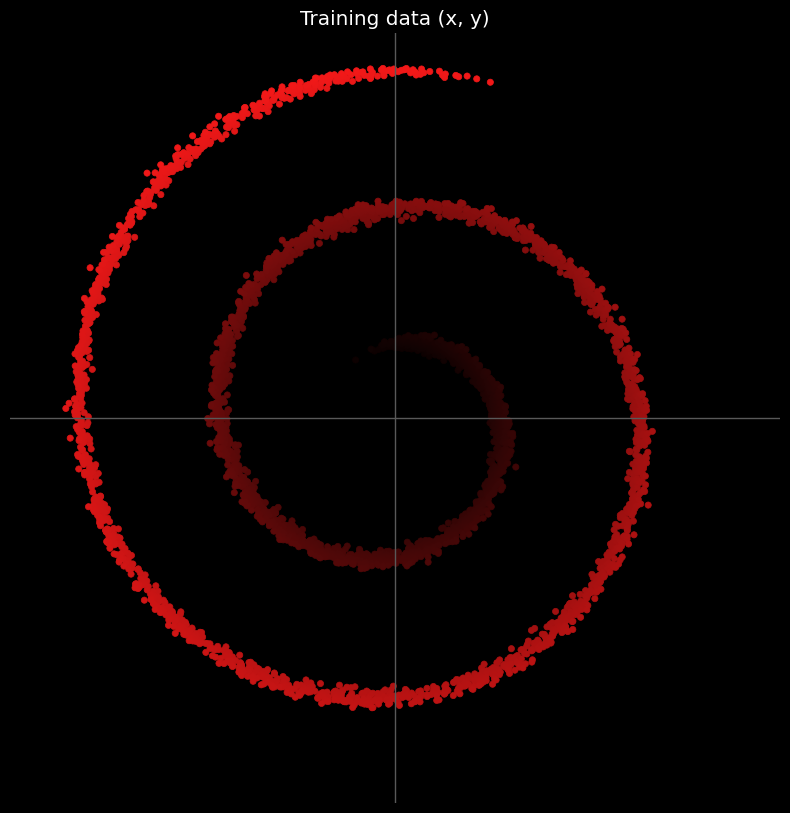

In [15]:
plot_data(X, y, point_colors=point_colors)
if save_plots:
    plt.savefig(os.path.join(output_dir, "data.png"), bbox_inches="tight")

## Set up single spiral data for model

In [16]:
# Transform single-spiral data to match the arc data structure

num_samples = 2 ** 12
batch_size = 2 ** 7
num_dims = 2

N = num_samples
S_manifold_pos = np.linspace(0, 1, N)
manifold_name_spiral = "spiral1"

manifold_function_spiral_1 = lambda s: (
    (0.8 * s + 0.2) * np.sin(2 * s * 2 * np.pi),
    (0.8 * s + 0.2) * np.cos(2 * s * 2 * np.pi),
)

noise_standard_deviation_spiral = [0.02, 0.02]

Z_input_data, _ = create_data_set(
    S=S_manifold_pos,
    manifold_function=manifold_function_spiral_1,
    noise_standard_deviation=noise_standard_deviation_spiral,
)

print("Single-spiral data structure:")
print(f"Z_input_data shape (data): {Z_input_data.shape}")
print(f"S_manifold_pos shape (positions): {S_manifold_pos.shape}")
print("manifold_function defined: yes")

Single-spiral data structure:
Z_input_data shape (data): (4096, 2)
S_manifold_pos shape (positions): (4096,)
manifold_function defined: yes


## Create S-shape data matching the single-spiral parameters (For Dual Disentangle)

In [17]:
Z2_input_data = np.copy(Z_input_data)
manifold_name_s = "sshape1"
k = 3.0

manifold_function_s_1 = lambda s: (
    s * 2.0 - 1.0,
    (s * 2.0 - 1.0) ** 3 - k * (s * 2.0 - 1.0),
)

noise_standard_deviation_s = [0.02, 0.02]

Z2_input_data, _ = create_data_set(
    S=S_manifold_pos,
    manifold_function=manifold_function_s_1,
    noise_standard_deviation=noise_standard_deviation_s,
)

batch_size = 64
dual_gen = self_supervised_dual_generator(Z_input_data, Z2_input_data, batch_size=batch_size, corr_target=(0.0, 0.9))
(Z1_batch_pair_a, Z2_batch_pair_b), target_corr = next(dual_gen)

print("Z1_batch_pair_a shape:", Z1_batch_pair_a.shape)
print("Z2_batch_pair_b shape:", Z2_batch_pair_b.shape)
print("Target correlation vector:", target_corr[0])

Z1_batch_pair_a shape: (64, 2)
Z2_batch_pair_b shape: (64, 2)
Target correlation vector: [0.  0.9]


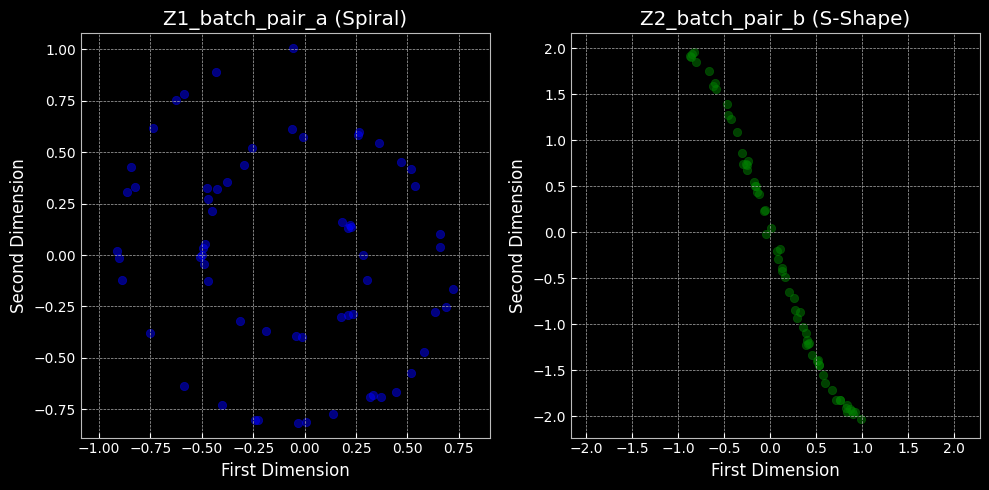

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].scatter(Z1_batch_pair_a[:, 0], Z1_batch_pair_a[:, 1], color="blue", alpha=0.5)
axs[0].set_title("Z1_batch_pair_a (Spiral)")
axs[0].set_xlabel("First Dimension")
axs[0].set_ylabel("Second Dimension")
axs[0].axis("equal")

axs[1].scatter(Z2_batch_pair_b[:, 0], Z2_batch_pair_b[:, 1], color="green", alpha=0.5)
axs[1].set_title("Z2_batch_pair_b (S-Shape)")
axs[1].set_xlabel("First Dimension")
axs[1].set_ylabel("Second Dimension")
axs[1].axis("equal")

plt.tight_layout()
plt.show()

## Dual Model Disentangle Calibration

In [19]:
def construct_layers(stage_count: int):
    return construct_flow_layers(stage_count=stage_count, num_dims=num_dims, hidden_units=128)

flow_layers_1 = construct_layers(stage_count=10)
flow_model_1 = FlowModel(flow_layers_1).to(device)

flow_layers_2 = construct_layers(stage_count=2)
flow_model_2 = FlowModel(flow_layers_2).to(device)

print("Flow model 1 and 2 successfully built.")

Flow model 1 and 2 successfully built.


In [25]:
flow_model_1.train()
flow_model_2.train()

# Prepare data on GPU
Z1_all = torch.tensor(Z_input_data, device=device, dtype=torch.float32)
Z2_all = torch.tensor(Z2_input_data, device=device, dtype=torch.float32)
target_corr_template = torch.tensor([0.0, 0.9], device=device, dtype=torch.float32)

optimizer = torch.optim.Adam(list(flow_model_1.parameters()) + list(flow_model_2.parameters()), lr=1e-3)

# Define a single training step for compilation
def train_step(z1_batch, z2_batch, target_corr_t):
    optimizer.zero_grad(set_to_none=True)

    z_tilde_1, j_1 = flow_model_1(z1_batch)
    z_tilde_2, j_2 = flow_model_2(z2_batch)

    corr_loss, observed_corr = factor_correlation_loss(
        z1=z_tilde_1,
        z2=z_tilde_2,
        y_target_corr=target_corr_t,
        dimensions_per_factor=dimensions_per_factor,
    )

    density_loss = gaussian_nll_with_logdet(z_tilde_1, j_1) + gaussian_nll_with_logdet(z_tilde_2, j_2)
    total_loss = corr_loss + density_weight * density_loss

    total_loss.backward()
    optimizer.step()
    return total_loss, corr_loss, density_loss, observed_corr

# Apply JIT compilation (PyTorch 2.0+)
fast_train_step = torch.compile(train_step)

# Parameters
batch_size = 512 # Increased for even better saturation
steps_per_epoch = 50
epochs = 500
dimensions_per_factor = [1, 1]
density_weight = 0.02

history_total, history_corr, history_density = [], [], []

for epoch in range(epochs):
    # Accumulate losses as tensors to avoid sync
    epoch_total_loss = torch.tensor(0.0, device=device)
    epoch_corr_loss = torch.tensor(0.0, device=device)
    epoch_density_loss = torch.tensor(0.0, device=device)

    for _ in range(steps_per_epoch):
        indices = torch.randint(0, len(Z1_all), (batch_size,), device=device)
        z1_batch, z2_batch = Z1_all[indices], Z2_all[indices]
        target_corr_t = target_corr_template.expand(batch_size, -1)

        t_loss, c_loss, d_loss, obs_corr = fast_train_step(z1_batch, z2_batch, target_corr_t)

        epoch_total_loss += t_loss
        epoch_corr_loss += c_loss
        epoch_density_loss += d_loss

    # Only sync with CPU once per epoch
    history_total.append((epoch_total_loss / steps_per_epoch).item())
    history_corr.append((epoch_corr_loss / steps_per_epoch).item())
    history_density.append((epoch_density_loss / steps_per_epoch).item())

    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:03d} | total={history_total[-1]:.4f} corr={history_corr[-1]:.4f} density={history_density[-1]:.4f} observed={obs_corr.detach().cpu().numpy()}")

print("Optimized Dual Training Complete.")

Epoch 000 | total=-0.0136 corr=0.0015 density=-0.7532 observed=[0.02504529 0.8589722 ]
Epoch 050 | total=-0.0131 corr=0.0016 density=-0.7335 observed=[0.01255321 0.8843881 ]
Epoch 100 | total=-0.0103 corr=0.0024 density=-0.6358 observed=[-0.06387773  0.88602114]
Epoch 150 | total=-0.0117 corr=0.0027 density=-0.7198 observed=[0.08208732 0.8749939 ]
Epoch 200 | total=-0.0088 corr=0.0023 density=-0.5549 observed=[-0.02271574  0.90979874]
Epoch 250 | total=-0.0159 corr=0.0016 density=-0.8747 observed=[-0.02175655  0.87010264]
Epoch 300 | total=-0.0112 corr=0.0021 density=-0.6655 observed=[-0.07478844  0.89904386]
Epoch 350 | total=-0.0166 corr=0.0014 density=-0.9036 observed=[0.05454613 0.87957776]
Epoch 400 | total=-0.0140 corr=0.0021 density=-0.8059 observed=[-0.09909721  0.8722009 ]
Epoch 450 | total=-0.0162 corr=0.0013 density=-0.8742 observed=[-0.07187463  0.8945694 ]
Epoch 499 | total=-0.0166 corr=0.0017 density=-0.9127 observed=[-0.09446839  0.87071943]
Optimized Dual Training Compl

In [28]:
checkpoint = {
    'epoch': epoch,
    'flow_model_1_state_dict': flow_model_1.state_dict(),
    'flow_model_2_state_dict': flow_model_2.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history_total': history_total,
    'history_corr': history_corr,
    'history_density': history_density
}

checkpoint_path = os.path.join(output_dir, 'dual_disentangle_checkpoint.pth')
torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to {checkpoint_path}")

Checkpoint saved to output_04-spiral_classification/pytorch_dual_corr_target/dual_disentangle_checkpoint.pth


In [29]:
checkpoint_path = os.path.join(output_dir, 'dual_disentangle_checkpoint.pth')
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    flow_model_1.load_state_dict(checkpoint['flow_model_1_state_dict'])
    flow_model_2.load_state_dict(checkpoint['flow_model_2_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    history_total = checkpoint['history_total']
    history_corr = checkpoint['history_corr']
    history_density = checkpoint['history_density']
    print(f"Checkpoint loaded from {checkpoint_path} (Last epoch: {epoch})")
else:
    print(f"No checkpoint found at {checkpoint_path}")

Checkpoint loaded from output_04-spiral_classification/pytorch_dual_corr_target/dual_disentangle_checkpoint.pth (Last epoch: 499)


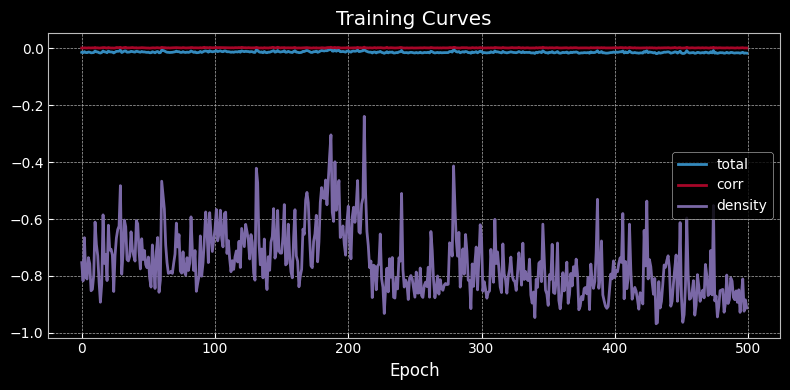

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(history_total, label="total")
plt.plot(history_corr, label="corr")
plt.plot(history_density, label="density")
plt.title("Training Curves")
plt.xlabel("Epoch")
plt.legend()
plt.tight_layout()
plt.show()

# Dual Disentanglement - 4 Subplot Verification

In [27]:
flow_model_1.eval()
flow_model_2.eval()

Z1_input_np = Z_input_data
Z2_input_np = Z2_input_data

with torch.no_grad():
    Z1_output_t, _ = flow_model_1(torch.tensor(Z1_input_np, device=device, dtype=torch.float32))
    Z2_output_t, _ = flow_model_2(torch.tensor(Z2_input_np, device=device, dtype=torch.float32))

Z1_output = Z1_output_t.detach().cpu().numpy()
Z2_output = Z2_output_t.detach().cpu().numpy()

s_color = (S_manifold_pos - np.min(S_manifold_pos)) / (np.max(S_manifold_pos) - np.min(S_manifold_pos) + 1e-12)

def dual_interactive_input_output_point(residual: float, position: float):
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle("Dual Disentanglement Inference")

    z_tilde_marker = torch.tensor([[residual, position]], device=device, dtype=torch.float32)
    with torch.no_grad():
        z1_marker = flow_model_1.invert(z_tilde_marker).detach().cpu().numpy()[0]
        z2_marker = flow_model_2.invert(z_tilde_marker).detach().cpu().numpy()[0]

    axs[0].scatter(Z1_input_np[:, 0], Z1_input_np[:, 1], c=s_color, cmap="turbo", s=10, alpha=0.85)
    axs[0].scatter([z1_marker[0]], [z1_marker[1]], color="blue", s=110, edgecolors="white", linewidths=1.0, zorder=5)
    axs[0].set_title("Input Space Z1 (Spiral)")
    axs[0].axis("equal")

    axs[1].scatter(Z1_output[:, 0], Z1_output[:, 1], c=s_color, cmap="turbo", s=10, alpha=0.85)
    axs[1].scatter([residual], [position], color="blue", s=110, edgecolors="white", linewidths=1.0, zorder=5)
    axs[1].set_title("Output Space Z1~")
    axs[1].set_xlabel("Residual Factor")
    axs[1].set_ylabel("Position Factor")
    axs[1].axis("equal")

    axs[2].scatter(Z2_output[:, 0], Z2_output[:, 1], c=s_color, cmap="turbo", s=10, alpha=0.85)
    axs[2].scatter([residual], [position], color="blue", s=110, edgecolors="white", linewidths=1.0, zorder=5)
    axs[2].set_title("Output Space Z2~")
    axs[2].set_xlabel("Residual Factor")
    axs[2].set_ylabel("Position Factor")
    axs[2].axis("equal")

    axs[3].scatter(Z2_input_np[:, 0], Z2_input_np[:, 1], c=s_color, cmap="turbo", s=10, alpha=0.85)
    axs[3].scatter([z2_marker[0]], [z2_marker[1]], color="blue", s=110, edgecolors="white", linewidths=1.0, zorder=5)
    axs[3].set_title("Input Space Z2 (S-Shape)")
    axs[3].axis("equal")

    plt.tight_layout()
    plt.show()

interact(
    dual_interactive_input_output_point,
    position=(-2.0, 2.0, 0.1),
    residual=(-2.0, 2.0, 0.1),
)

interactive(children=(FloatSlider(value=0.0, description='residual', max=2.0, min=-2.0), FloatSlider(value=0.0…

<function __main__.dual_interactive_input_output_point(residual: float, position: float)>